# 🦙 Local RAG Q&A Chatbot: Tutorial Notebook

A **fully local** question-answering bot that answers from company documents.
Nothing leaves the machine. The LLM, the embeddings, and the vector database all run locally.

**Stack**
- **Ollama**: runs the LLM (`llama3.1:8b`) and the embedding model locally
- **LangChain**: wires the pipeline together
- **Chroma**: local vector database (stores the documents as searchable vectors)
- **Jupyter**: where the build and experiments happen

### What is RAG, in one picture?
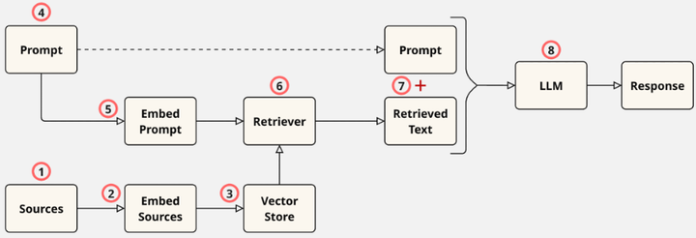

Without RAG, the model answers only from what it was trained on. With RAG, the most
relevant chunks of the documents get retrieved and handed to the model as context, so answers stay
grounded in the data. Each numbered step below gets built one cell at a time.

## Step 0: Before running anything

This notebook assumes the terminal setup is already done (see the project `README.md`):

1. Installed **Ollama** for Windows and it's running (the llama icon shows in the system tray).
2. Pulled the two models:
   ```
   ollama pull llama3.1:8b
   ollama pull nomic-embed-text
   ```
3. Created and activated a virtual environment and installed the Python packages.

The first cell just checks that Ollama is alive and the models are present. If it fails,
go back to the README first. Don't continue until this passes.

In [1]:
# --- Sanity check: is Ollama running and are our models installed? ---
import requests

try:
    resp = requests.get("http://localhost:11434/api/tags", timeout=5)
    resp.raise_for_status()
    installed = [m["name"] for m in resp.json().get("models", [])]
    print("✅ Ollama is running.")
    print("Installed models:", installed)
    for needed in ("llama3.1:8b", "nomic-embed-text:latest"):
        base = needed.split(":")[0]
        if any(m.startswith(base) for m in installed):
            print(f"  ✅ found a model matching '{base}'")
        else:
            print(f"  ❌ '{base}' not found, run:  ollama pull {needed.replace(':latest','')}")
except Exception as e:
    print("❌ Could not reach Ollama at http://localhost:11434")
    print("   Make sure the Ollama app is running, then re-run this cell.")
    print("   Error:", e)

✅ Ollama is running.
Installed models: ['nomic-embed-text:latest', 'llama3.1:8b', 'qwen3-coder:30b', 'qwen2.5-coder:7b']
  ✅ found a model matching 'llama3.1'
  ✅ found a model matching 'nomic-embed-text'


## Step 1: Install the Python packages (only if the README was skipped)

Best practice is to install these in the terminal (inside the activated venv) using
`pip install -r requirements.txt`. Running it here once also works. The `%pip` magic installs
into the same environment this notebook is using.

If they were already installed via the README, **skip this cell.**

In [ ]:
# Run once if needed. Safe to skip if installed via requirements.txt in the terminal.
%pip install -q \
    langchain langchain-core langchain-community \
    langchain-ollama langchain-chroma langchain-text-splitters \
    pypdf docx2txt chromadb
print("Done. Restart the kernel if this was a fresh install.")

## Step 2: Configuration

All the "knobs" live in one place. That's a good habit. Trying a bigger model
or different chunk sizes means changing one cell instead of hunting through the notebook.

- **`LLM_MODEL`**: the chat model that writes answers. `llama3.1:8b` is a great balance for an
  RTX 3050 + 64 GB RAM. If answers feel slow, try `llama3.2:3b`. For more quality, `qwen2.5:14b`.
- **`EMBED_MODEL`**: turns text into vectors. This stays the **same** for indexing and querying.
- **`CHUNK_SIZE` / `CHUNK_OVERLAP`**: how documents get cut into pieces (explained in Step 4).
- **`N_RESULTS`**: how many chunks to retrieve per question.

In [5]:
from pathlib import Path

# --- Models (must match what was pulled in Ollama) ---
LLM_MODEL   = "llama3.1:8b"
EMBED_MODEL = "nomic-embed-text"

# --- Paths ---
DATA_DIR = Path("..") / "data"        # company documents live here
DB_DIR   = "../chroma_db"             # the vector database is persisted to this folder

# --- Chunking & retrieval knobs ---
CHUNK_SIZE    = 1000             # characters per chunk
CHUNK_OVERLAP = 150             # characters shared between neighbouring chunks
N_RESULTS     = 4               # how many chunks to feed the model per question

print("Config loaded. Documents folder:", DATA_DIR.resolve())

Config loaded. Documents folder: C:\dev\Learning\rag-qa-bot\data


## Step 3: Load the documents

The files are a **mix of formats**, so this handles PDF, Word (`.docx`), plain text, and
Markdown. LangChain provides a dedicated *loader* for each type:

| Extension        | Loader           |
|------------------|------------------|
| `.pdf`           | `PyPDFLoader`    |
| `.docx`          | `Docx2txtLoader` |
| `.txt` / `.md`   | `TextLoader`     |

The `data/` folder gets walked, the right loader picks per file, and everything loads into a list of
LangChain `Document` objects. Each Document carries the text **plus metadata** (like which file it
came from). That metadata is what makes source citations possible later.

In [6]:
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader, TextLoader

def load_documents(folder: Path):
    documents = []
    files = [p for p in folder.rglob("*") if p.is_file()]
    if not files:
        print(f"⚠️  No files found in {folder.resolve()}. Add some documents and re-run.")
        return documents

    for path in files:
        suffix = path.suffix.lower()
        try:
            if suffix == ".pdf":
                loader = PyPDFLoader(str(path))
            elif suffix == ".docx":
                loader = Docx2txtLoader(str(path))
            elif suffix in (".txt", ".md"):
                loader = TextLoader(str(path), autodetect_encoding=True)
            else:
                print(f"  ↷ skipping unsupported file: {path.name}")
                continue
            loaded = loader.load()
            documents.extend(loaded)
            print(f"  ✅ loaded {path.name}  ({len(loaded)} document object(s))")
        except Exception as e:
            print(f"  ❌ failed on {path.name}: {e}")

    print(f"\nTotal document objects loaded: {len(documents)}")
    return documents

docs = load_documents(DATA_DIR)

  ✅ loaded sample_company_handbook.md  (1 document object(s))

Total document objects loaded: 1


## Step 4: Split the documents into chunks

Why split at all? Two reasons:
1. **Precision**: retrieving a whole 40-page PDF to answer one question is wasteful and dilutes the
   context. Small chunks pull just the relevant paragraphs.
2. **Model limits**: only so much text fits into the prompt.

`RecursiveCharacterTextSplitter` handles this. It tries to split on natural boundaries (paragraphs,
then sentences, then words) so chunks stay coherent.

- **`chunk_size`**: target characters per chunk. Smaller means more precise but more fragmented.
- **`chunk_overlap`**: a few characters repeated between neighbours so a sentence split across the
  boundary isn't lost. Around 10 to 15% of chunk size is a good rule of thumb.

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],  # try these boundaries in order
)

chunks = splitter.split_documents(docs)
print(f"Split {len(docs)} document object(s) into {len(chunks)} chunks.")
if chunks:
    print("\n--- Example chunk ---")
    print("Source:", chunks[0].metadata.get("source"))
    print(chunks[0].page_content[:300], "...")

Split 1 document object(s) into 2 chunks.

--- Example chunk ---
Source: ..\data\sample_company_handbook.md
# Acme Corp â€” Employee & Customer Handbook (Sample)

This is a **sample** document so the notebook runs out of the box. Replace the files in this
`data/` folder with your own company documents (PDF, Word, text, or Markdown).

## Refund Policy

Customers may request a full refund within **30 days** ...


## Step 5: Embed the chunks and store them in Chroma

An **embedding** is a list of numbers (a vector) that captures the *meaning* of a piece of text.
Texts with similar meaning end up close together in vector space. That's the magic behind
searching by meaning instead of exact keywords.

Ollama's `nomic-embed-text` model embeds each chunk, then the vectors get stored in **Chroma**,
a local vector database. Passing `persist_directory` saves the database to disk. After that it
loads instantly instead of re-embedding everything.

> **First run is the slow one.** Embedding every chunk takes a moment. After that it's cached on disk.

In [8]:
from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma

embeddings = OllamaEmbeddings(model=EMBED_MODEL)

# Build the vector store from our chunks and persist it to disk.
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=DB_DIR,
    collection_name="company_docs",
)
print(f"✅ Vector store ready with {vectorstore._collection.count()} vectors, saved to '{DB_DIR}/'.")

✅ Vector store ready with 2 vectors, saved to '../chroma_db/'.


### (Later runs) Load the existing database instead of rebuilding

Once the database exists on disk, re-running Steps 3 to 5 isn't needed. In a fresh session, just
run Step 2 (config) and then this cell to reconnect to the saved vectors. *(Skip it for now, since
`vectorstore` is already in memory.)*

In [ ]:
# Use this in future sessions to skip re-indexing:
from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma
embeddings = OllamaEmbeddings(model=EMBED_MODEL)
vectorstore = Chroma(
    persist_directory=DB_DIR,
    embedding_function=embeddings,
    collection_name="company_docs",
)
print("Reconnected to", vectorstore._collection.count(), "vectors.")

## Step 6: Create a retriever and test it

A **retriever** is a thin wrapper around the vector store that, given a question, returns the
`N_RESULTS` most similar chunks. Time to create one and sanity-check it *before* involving the LLM.
If retrieval returns junk, the answer will be junk, so this piece is worth testing on its own.

In [9]:
retriever = vectorstore.as_retriever(search_kwargs={"k": N_RESULTS})

# Try a question and see which chunks come back:
test_question = "What is the company's refund policy?"   # change to something in the docs
hits = retriever.invoke(test_question)

print(f"Top {len(hits)} chunks for: {test_question!r}\n")
for i, doc in enumerate(hits, 1):
    src = doc.metadata.get("source", "unknown")
    print(f"[{i}] from {src}")
    print("   ", doc.page_content[:200].replace("\n", " "), "...\n")

Top 2 chunks for: "What is the company's refund policy?"

[1] from ..\data\sample_company_handbook.md
    # Acme Corp â€” Employee & Customer Handbook (Sample)  This is a **sample** document so the notebook runs out of the box. Replace the files in this `data/` folder with your own company documents (PDF, ...

[2] from ..\data\sample_company_handbook.md
    ## Vacation and Leave  Full-time employees accrue **25 days** of paid vacation per year, plus public holidays. Unused vacation of up to 5 days may be carried into the following year. Sick leave is sep ...



## Step 7: Write the prompt template

This is where **prompt templates** come in. A template is a
reusable prompt with placeholders filled in at runtime. This one has two placeholders:

- `{context}`: the retrieved chunks get injected here
- `{question}`: the user's question

The **system message** sets the bot's behaviour. It explicitly says to answer *only* from
the provided context and to admit when the answer isn't there. That's what keeps a RAG bot honest and
stops it from making things up.

In [10]:
from langchain_core.prompts import ChatPromptTemplate

SYSTEM_PROMPT = (
    "You are a helpful assistant for answering questions about internal company documents. "
    "Use ONLY the pieces of context provided below to answer the question. "
    "If the answer is not contained in the context, say you don't know based on the available "
    "documents, do not invent information. Keep answers concise and cite which document you used."
)

prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human", "Context:\n{context}\n\nQuestion: {question}\n\nAnswer:"),
])

print(prompt.format(context="<retrieved chunks go here>", question="<user question>"))

System: You are a helpful assistant for answering questions about internal company documents. Use ONLY the pieces of context provided below to answer the question. If the answer is not contained in the context, say you don't know based on the available documents, do not invent information. Keep answers concise and cite which document you used.
Human: Context:
<retrieved chunks go here>

Question: <user question>

Answer:


## Step 8: Assemble the RAG chain

Everything connects here using **LCEL** (LangChain Expression Language), where the `|` pipe passes
output from one step to the next, just like a Unix pipe. The chain does:

```
{context: retriever→formatted, question: passthrough}  →  prompt  →  LLM  →  plain text
```

`format_docs` turns the list of retrieved chunks into one tidy string (and tags each with its source
so the model can cite it). `StrOutputParser` just extracts the plain-text answer from the model's
response object.

In [11]:
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

llm = ChatOllama(model=LLM_MODEL, temperature=0)  # temperature=0 → focused, less "creative"

def format_docs(docs):
    # Combine retrieved chunks into a single context string, labelled by source.
    blocks = []
    for d in docs:
        src = d.metadata.get("source", "unknown")
        blocks.append(f"[Source: {src}]\n{d.page_content}")
    return "\n\n---\n\n".join(blocks)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print("✅ RAG chain assembled and ready.")

✅ RAG chain assembled and ready.


## Step 9: Ask a question!

Everything comes together here. Change the question to something answerable from the documents.

In [12]:
question = "What is the company's refund policy?"   # ← edit this
answer = rag_chain.invoke(question)
print(answer)

Customers may request a full refund within 30 days of purchase, provided the product is unused and in its original packaging. Refunds are processed to the original payment method within 5–7 business days. Digital products are non-refundable once downloaded, except where required by law. [Source: ..\data\sample_company_handbook.md]


### A tidier helper that also shows its sources

Good RAG bots are *transparent*. They show which documents an answer came from, so it can be verified.
This helper returns the answer **and** the source chunks.

In [13]:
def ask(question: str, show_sources: bool = True):
    answer = rag_chain.invoke(question)
    print("❓", question)
    print("\n💬", answer)
    if show_sources:
        sources = retriever.invoke(question)
        seen = set()
        print("\n📄 Sources:")
        for d in sources:
            src = d.metadata.get("source", "unknown")
            if src not in seen:
                print("  -", src)
                seen.add(src)
    return answer

_ = ask("What is the company's refund policy?")

❓ What is the company's refund policy?

💬 Customers may request a full refund within 30 days of purchase, provided the product is unused and in its original packaging. Refunds are processed to the original payment method within 5–7 business days. Digital products are non-refundable once downloaded, except where required by law. [Source: ..\data\sample_company_handbook.md]

📄 Sources:
  - ..\data\sample_company_handbook.md


## Step 10: A simple interactive chat loop (optional)

Run this cell to chat with the documents in a loop. Type `quit` (or `exit`) to stop.

> Note: each question is answered independently. This bot has no conversational memory yet.
> Adding memory (so it understands follow-ups like "what about for members?") is a great next step,
> listed below.

In [ ]:
print("Ask questions about the documents. Type 'quit' to stop.\n")
while True:
    try:
        q = input("You: ").strip()
    except (EOFError, KeyboardInterrupt):
        break
    if q.lower() in {"quit", "exit", ""}:
        print("Goodbye!")
        break
    print("Bot:", rag_chain.invoke(q), "\n")

## 🎉 A local RAG Q&A bot, built!

Recap of what each piece did:
1 to 3. **Loaded** the mixed-format documents.
4. **Split** them into overlapping chunks.
5. **Embedded** the chunks and stored them in a local **Chroma** database.
6. **Retrieved** the most relevant chunks per question.
7. **Prompt template** kept the bot grounded and honest.
8. **LCEL chain** tied retrieval, prompt, and LLM together.
9 to 10. **Asked questions** and got answers cited from the documents.

### Ideas to extend it (in rough order of difficulty)
- **Conversational memory**: handle follow-up questions.
- **Better citations**: show the exact snippet and page number used.
- **A UI**: wrap it in [Streamlit](https://streamlit.io/) for a proper chat window.
- **Tune retrieval**: experiment with `N_RESULTS`, `CHUNK_SIZE`, or try `MultiQueryRetriever`.
- **Evaluate quality**: measure answer accuracy with a tool like Ragas.
- **Package with Docker**: for reproducible deployment once it's solid.